In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Fig - 1.C (Bland Altman Plot)

In [3]:
df = pd.read_csv('Stem_cell_validation.csv',
                  index_col=(0))
df

,stem,actual,tumor
GSM871443.CEL.gz,1.000000,1,0.000000
GSM871444.CEL.gz,0.999267,1,0.000733
GSM871445.CEL.gz,1.000000,1,0.000000
GSM871450.CEL.gz,0.798894,1,0.201106
GSM871483.CEL.gz,0.918496,1,0.081504
GSM871489.CEL.gz,0.594310,1,0.405690
GSM871512.CEL.gz,0.813401,1,0.186599
GSM871513.CEL.gz,0.818034,1,0.181966
GSM2121006_Wicha_001_2-S-D-AP.CEL.gz,0.992142,1,0.007858
GSM2121007_Wicha_002_3-S-D-AP.CEL.gz,0.979488,1,0.020512


Text(0.5, 47.7222222222222, 'Difference between methods')

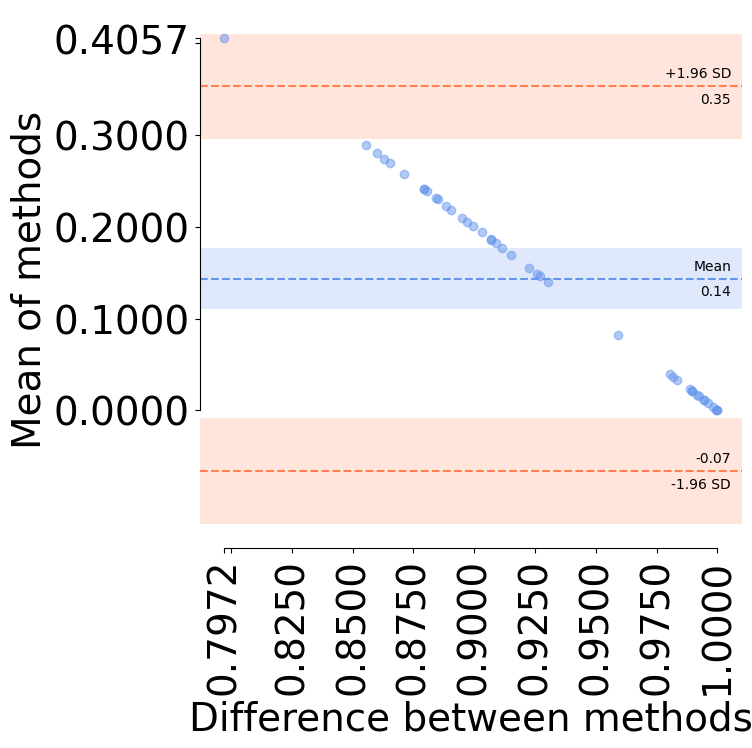

In [6]:
import pyCompare 

fig, ax = plt.subplots(figsize=(7, 7))
bland_altman_plot = pyCompare.blandAltman(df['actual'], df['stem'],
                                          limitOfAgreement=1.96,
                                          confidenceInterval=95,
                                          confidenceIntervalMethod='approximate',
                                          detrend=None,
                                          percentage=False, ax=ax)


ax.tick_params(axis='x', labelsize=28, rotation=90)
ax.tick_params(axis='y', labelsize=28)
ax.set_ylabel('Mean of methods', fontsize=28)
ax.set_xlabel('Difference between methods', fontsize=28)
# plt.savefig('brand_altman_plot.svg', dpi=600, bbox_inches='tight')

Fig - 1.E (Performance analysis of different ML models)

In [9]:
df = pd.read_csv('model_result.csv')
df = pd.melt(df, id_vars='Run', value_vars=df.iloc[:,1:].columns)
df

,Run,variable,value
0,Run 1,LR_Accuracy,0.969651
1,Run 2,LR_Accuracy,0.974203
2,Run 3,LR_Accuracy,0.972686
3,Run 4,LR_Accuracy,0.977238
4,Run 5,LR_Accuracy,0.974164
...,...,...,...
145,Run 1,XGB_Recall,0.933000
146,Run 2,XGB_Recall,0.935000
147,Run 3,XGB_Recall,0.929000
148,Run 4,XGB_Recall,0.929000


In [12]:
fig = px.scatter(df, x="variable", y="value", color="Run")
fig.update_layout(
    showlegend=True,
    plot_bgcolor='rgba(0, 0, 0, 0)',
)

fig.update_xaxes(showgrid=True, gridcolor='gray', griddash='dot',
                 title_font=dict(size=16, family="Calibre Light"), title_text="", tickfont=dict(size=14))
fig.update_yaxes(showgrid=True, gridcolor='gray', griddash='dot',
                 title_font=dict(size=25, family="Calibre Light"), title_text="Prediction Parameter",
                tickfont=dict(size=14))
scaling_factor = 12  
sizes = df['value'] * scaling_factor

fig.update_traces(marker=dict(size=sizes, symbol='square'))

y_axis_limit = (0.85, 1)
fig.update_yaxes(range=y_axis_limit)
fig.show()
# pio.write_image(fig, 'prediction_parameter.png', scale=20)

Fig - 2.A (Stem Cell Frequency and types in each types of cancer)

In [15]:
df = pd.read_csv('22_analysis.csv')
df

,Unnamed: 0,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
0,TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
1,TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
2,TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
3,TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
4,TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8781,TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
8782,TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
8783,TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
8784,TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [16]:
first_element_indices = df.groupby('Cancer').apply(lambda group: group.index[0]).reset_index(name='FirstElementIndex')
first_element_indices

,Cancer,FirstElementIndex
0,BRCA,1608
1,CESC,1299
2,CHOL,5273
3,COADREAD,3476
4,DLBC,6120
5,ESCA,5318
6,GBM,8217
7,HNSC,6698
8,KICH,8388
9,KIRC,5514


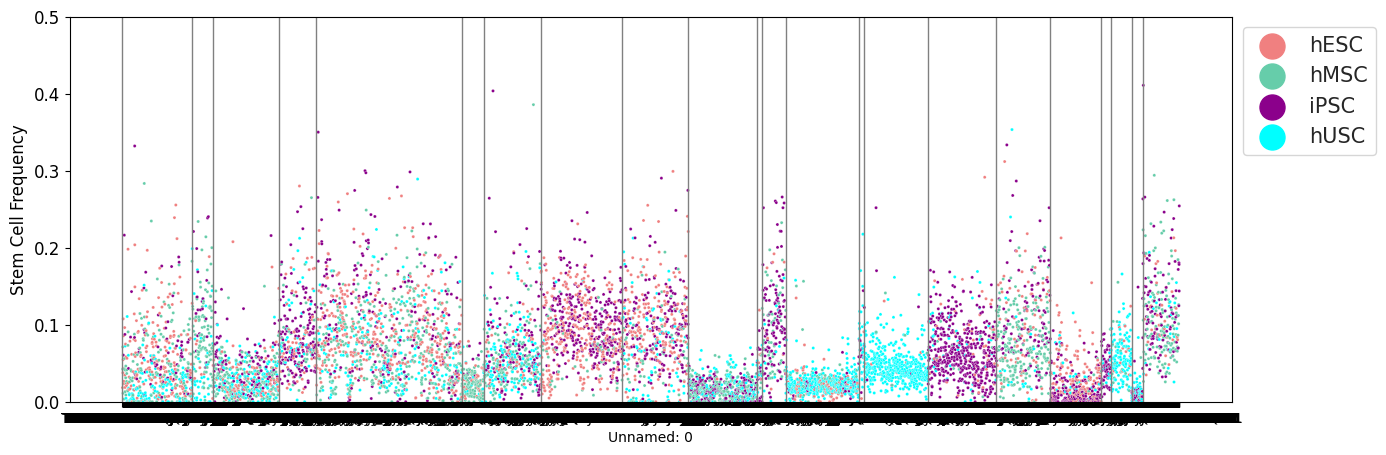

In [17]:
from matplotlib.font_manager import FontProperties

custom_palette = {
    'iPSC': 'darkmagenta',
    'hESC': 'lightcoral',
    'hMSC': 'mediumaquamarine',
    'hUSC': 'aqua'
}

fig, ax = plt.subplots(figsize=(15, 5))
sns.set(style='white')
plt.ylim(0, 0.5)
sns.scatterplot(x='Unnamed: 0', y='stem', data=df, hue='predicted_label',
                palette=custom_palette, s = 5, alpha=1, ax=ax)

for i in first_element_indices['FirstElementIndex']:
    plt.axvline(x=i, color='gray', linewidth=1)

ax.set_ylabel('Stem Cell Frequency', fontsize=12)  

ax.tick_params(axis='y', labelsize=12)

legend_font = FontProperties(size=15)
plt.legend(fontsize=5, loc='upper left', bbox_to_anchor=(1, 1), prop=legend_font, markerscale=3)

# plt.savefig('stem_cell_panaroma.png', dpi=600, bbox_inches='tight')

Fig - 2.B (Freq. of each Stem Cell types in each types of cancer)

In [18]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [19]:
cancer_type = ['LUAD', 'LAML', 'PRAD', 'CESC', 'BRCA', 'PAAD', 'SKCM', 'COADREAD',
       'LUSC', 'THCA', 'CHOL', 'ESCA', 'KIRC', 'DLBC', 'LGG', 'HNSC',
       'STAD', 'LIHC', 'UVM', 'GBM', 'KICH', 'OV']

In [20]:
group = df.groupby('Cancer')

counts = []
for j in cancer_type:
    df = group.get_group(j)
    df = df['predicted_label'].value_counts()
    df = (df.reindex(['iPSC', 'hMSC', 'hUSC', 'hESC'], fill_value=0).values)
    counts.append(df)

In [22]:
stack = pd.DataFrame(counts)
stack.columns = ['iPSC', 'hMSC', 'hUSC', 'hESC']
stack.index = cancer_type
stack = stack.div(stack.sum(axis=1), axis=0)
stack = stack.reset_index()
stack

,index,iPSC,hMSC,hUSC,hESC
0,LUAD,0.119792,0.289931,0.218750,0.371528
1,LAML,0.115607,0.583815,0.236994,0.063584
2,PRAD,0.198182,0.340000,0.267273,0.194545
3,CESC,0.514563,0.100324,0.168285,0.216828
4,BRCA,0.175743,0.326733,0.142739,0.354785
5,PAAD,0.043716,0.688525,0.081967,0.185792
6,SKCM,0.247357,0.298097,0.304440,0.150106
7,COADREAD,0.435746,0.073855,0.005908,0.484490
8,LUSC,0.315217,0.128623,0.170290,0.385870
9,THCA,0.299296,0.473592,0.223592,0.003521


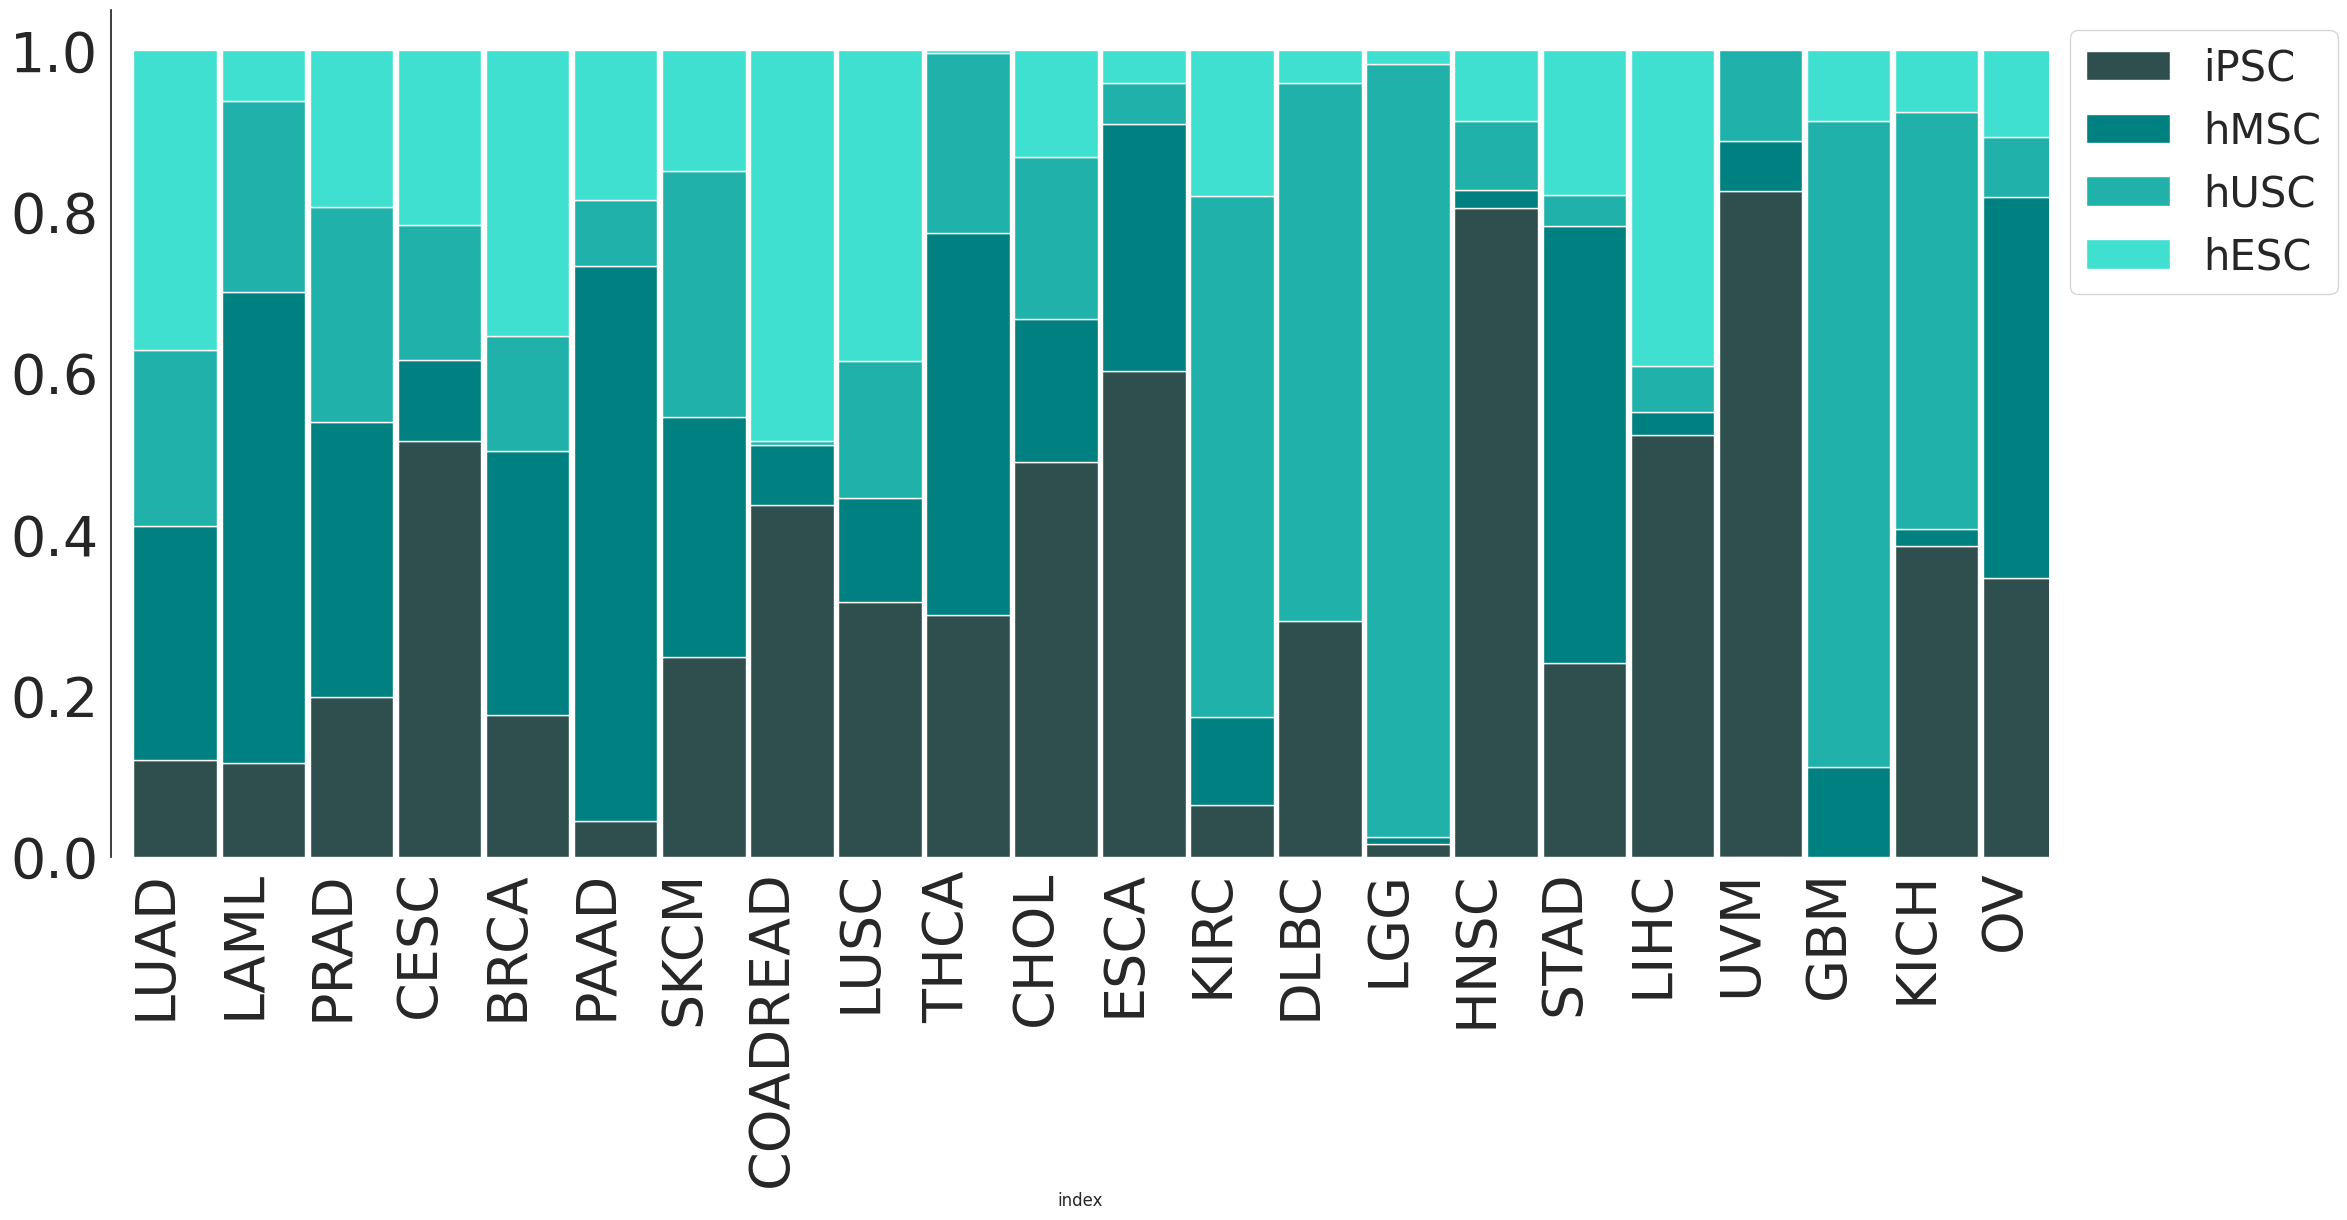

In [23]:
fig, ax = plt.subplots(figsize=(25, 11))
ax = stack.plot(x='index', kind='bar', stacked=True, ax=ax,
                color=['darkslategrey', 'teal', 'lightseagreen', 'turquoise'])
bar_width = 0.95
for container in ax.containers:
    plt.setp(container, width=bar_width)
ax.tick_params(axis='y', labelsize=40)
ax.tick_params(axis='x', labelsize=40)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

legend = ax.legend(prop={'size': 30})
legend.set_bbox_to_anchor((1, 1))

# plt.savefig('cancer_stack_percent_plot.png', dpi=600, bbox_inches='tight')

Fig - 2.C (Anatogram made using online webserver)

Fig - 2.D (Cancer Cell Frequency and types in each types of cancer)

Fig - 2.E (Each Cancer - primary, secondary and stem frequencies)

In [5]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
df = df[['Cancer', 'stem', 'PRAD', 'STAD', 'KICH', 'SKCM', 'DLBC', 'THCA',
       'ESCA', 'PAAD', 'LUAD', 'UVM', 'COADREAD', 'KIRC', 'OV', 'LAML', 'GBM',
       'CESC', 'CHOL', 'LIHC', 'BRCA', 'LGG', 'HNSC']]
df

,Cancer,stem,PRAD,STAD,KICH,SKCM,DLBC,THCA,ESCA,PAAD,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,0.018238,0.000000,0.000000,0.000000,0.182425,0.000000,0.084537,0.0,0.122675,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,0.042426,0.000000,0.017292,0.000000,0.154744,0.000000,0.114880,0.0,0.136823,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,0.071180,0.000000,0.000000,0.000000,0.259081,0.001230,0.150889,0.0,0.182184,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,0.037569,0.000000,0.007157,0.000000,0.319247,0.008343,0.144649,0.0,0.165452,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,0.010948,0.000000,0.016429,0.020596,0.223112,0.000000,0.090601,0.0,0.063075,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,0.124652,0.000000,0.000000,0.000000,0.162338,0.000000,0.191095,0.0,0.088913,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,0.180374,0.000000,0.000000,0.000000,0.167290,0.000000,0.162523,0.0,0.008345,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,0.178266,0.000000,0.000000,0.016234,0.081833,0.000000,0.039227,0.0,0.017627,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,0.143781,0.000000,0.000000,0.013441,0.074328,0.000000,0.071757,0.0,0.045307,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [3]:
colors = ['crimson', 'silver', 'rosybrown', 'maroon', 'tomato', 'coral', 'sandybrown', 'darkorange', 'tan',
          'darkgoldenrod', 'olive', 'yellow', 'darkolivegreen', 'darkseagreen', 'aquamarine',
          'darkslategray','cadetblue', 'steelblue', 'navy', 'mediumpurple', 'magenta']

In [6]:
from scipy.stats import gmean

grouped = df.groupby('Cancer')

Primary = []
Secondary = []
Stem = []
for j in df.iloc[:,2:].columns:
    if j == 'LUAD':
        df1 = pd.concat([group for (name, group) in grouped if name in ['LUAD', 'LUSC']])
    else:
        df1 = grouped.get_group(j)
    med_pr = np.mean(df1[j])
    med_s = np.mean(df1['stem'])
    df1 = df1.drop([j], axis=1)
    med_se = df1.iloc[:,2:].sum(axis=1)
    med_se = np.mean(med_se)
    Primary.append(med_pr)
    Secondary.append(med_se)
    Stem.append(med_s)

In [7]:
stack = pd.DataFrame([Primary, Secondary, Stem]).T
stack.columns = ['Primary', 'Secondary', 'Stem']
stack.index = df.iloc[:,2:].columns
stack = stack.reset_index()
stack

,index,Primary,Secondary,Stem
0,PRAD,0.145459,0.787616,0.032748
1,STAD,0.015324,0.848969,0.087880
2,KICH,0.439236,0.524035,0.014667
3,SKCM,0.616649,0.282263,0.063048
4,DLBC,0.147504,0.368205,0.074135
5,THCA,0.090316,0.850824,0.016230
6,ESCA,0.069210,0.796882,0.101638
7,PAAD,0.310102,0.616765,0.024211
8,LUAD,0.096359,0.775923,0.067069
9,UVM,0.445816,0.497495,0.044347


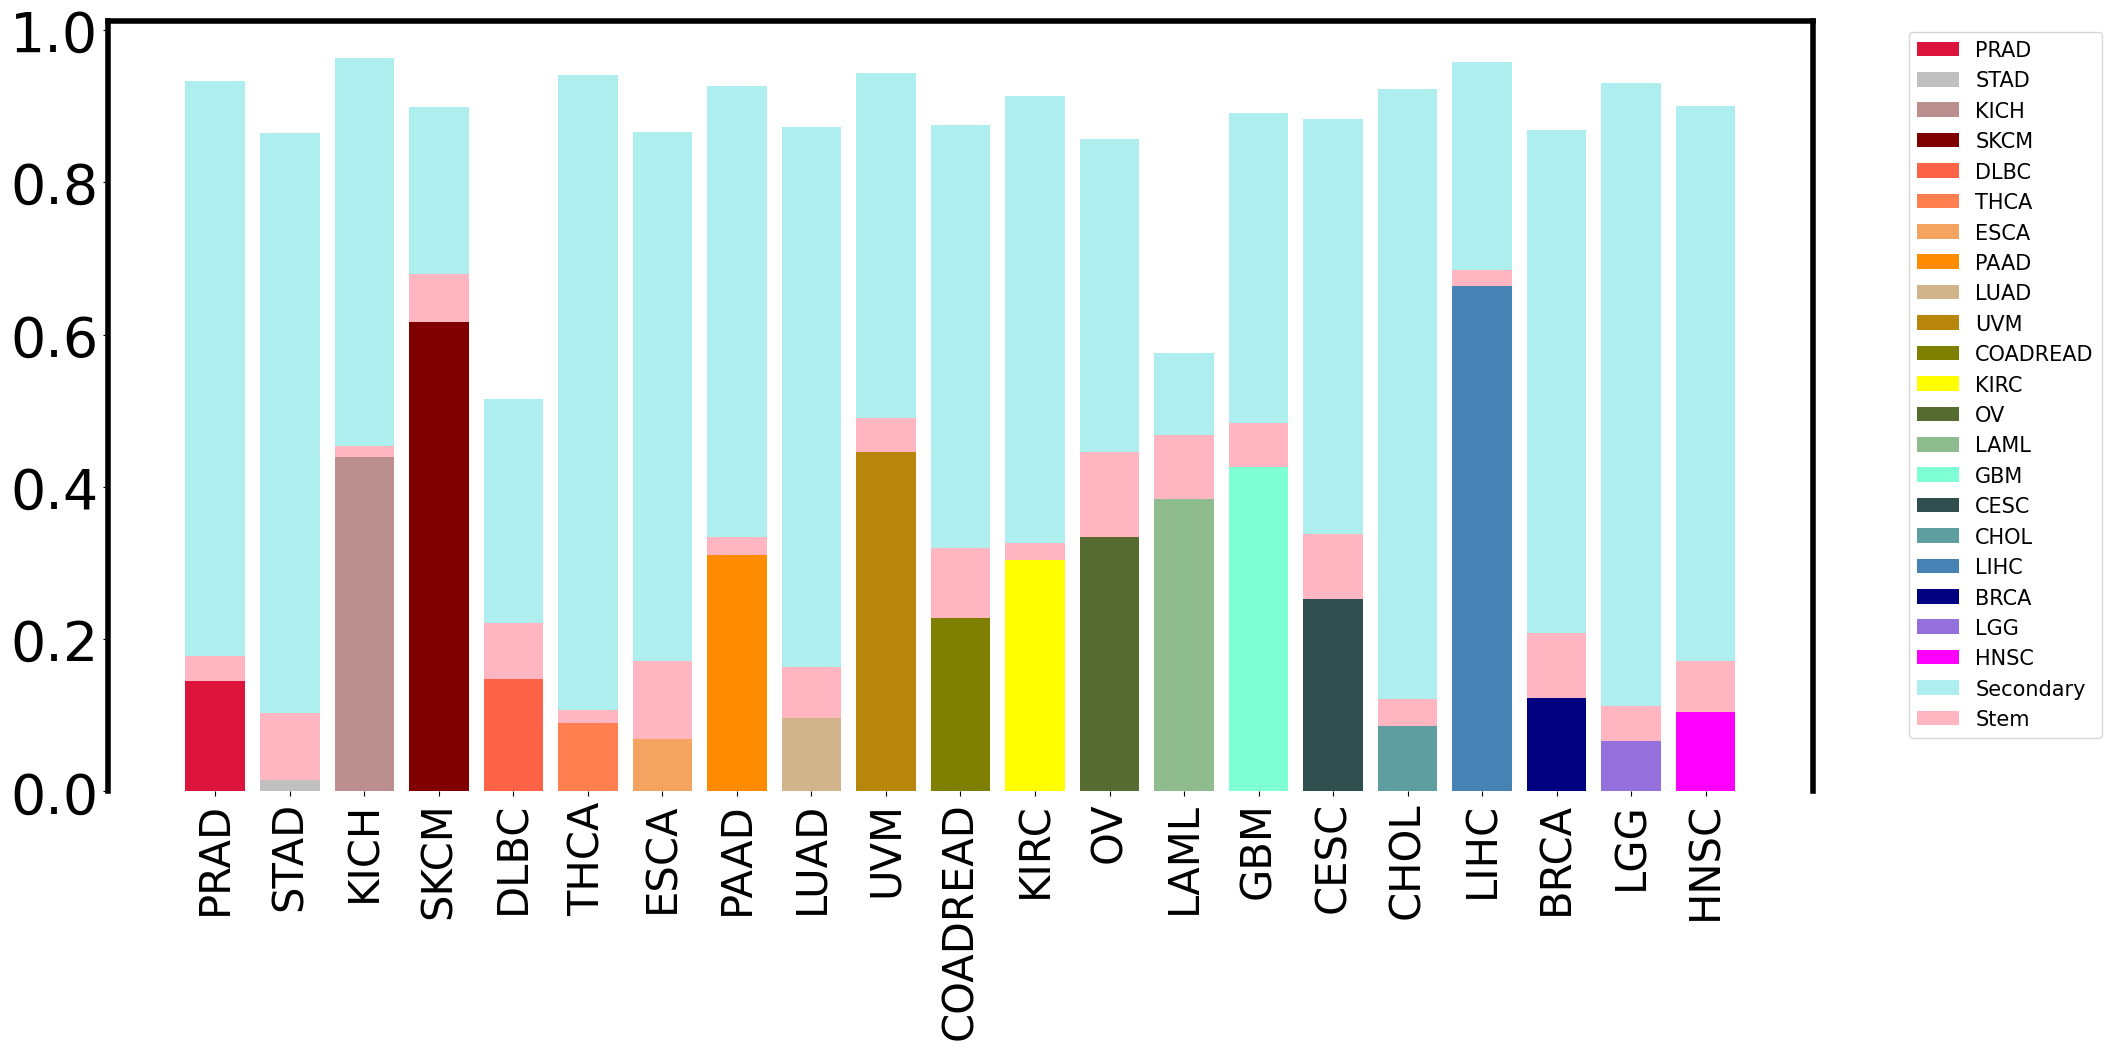

In [8]:
fig, ax = plt.subplots(figsize=(22, 10))
for i, index in enumerate(stack['index']):
    ax.bar(index, stack.at[i, 'Primary'], color=colors[i], label=index)
for col, color in [('Secondary', 'paleturquoise'), ('Stem', 'lightpink')]:
    ax.bar(stack['index'], stack[col], bottom=stack['Primary'], label=col, color=color)

ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left', fontsize=15)
ax.tick_params(axis='x', labelsize=30, rotation=90)
ax.tick_params(axis='y', labelsize=40)
for spine in ax.spines.values():
    spine.set_linewidth(4)
ax.spines['bottom'].set_visible(False)

plt.show()

Fig - 3.A (Stacked Line Plot CSC Freq. vs AJCC tumor Stage)

In [9]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [15]:
patient_cut = [i[:-3] for i in df.index]
patient_cut

['TCGA-05-4244',
 'TCGA-05-4249',
 'TCGA-05-4250',
 'TCGA-05-4382',
 'TCGA-05-4384',
 'TCGA-05-4389',
 'TCGA-05-4390',
 'TCGA-05-4395',
 'TCGA-05-4396',
 'TCGA-05-4397',
 'TCGA-05-4398',
 'TCGA-05-4402',
 'TCGA-05-4403',
 'TCGA-05-4405',
 'TCGA-05-4410',
 'TCGA-05-4415',
 'TCGA-05-4417',
 'TCGA-05-4418',
 'TCGA-05-4420',
 'TCGA-05-4422',
 'TCGA-05-4424',
 'TCGA-05-4425',
 'TCGA-05-4426',
 'TCGA-05-4427',
 'TCGA-05-4430',
 'TCGA-05-4432',
 'TCGA-05-4433',
 'TCGA-05-4434',
 'TCGA-05-5420',
 'TCGA-05-5423',
 'TCGA-05-5425',
 'TCGA-05-5428',
 'TCGA-05-5429',
 'TCGA-05-5715',
 'TCGA-35-3615',
 'TCGA-35-4122',
 'TCGA-35-4123',
 'TCGA-35-5375',
 'TCGA-38-4625',
 'TCGA-38-4625',
 'TCGA-38-4626',
 'TCGA-38-4626',
 'TCGA-38-4627',
 'TCGA-38-4627',
 'TCGA-38-4628',
 'TCGA-38-4629',
 'TCGA-38-4630',
 'TCGA-38-4631',
 'TCGA-38-4632',
 'TCGA-38-4632',
 'TCGA-38-6178',
 'TCGA-38-7271',
 'TCGA-38-A44F',
 'TCGA-44-2655',
 'TCGA-44-2655',
 'TCGA-44-2656',
 'TCGA-44-2657',
 'TCGA-44-2657',
 'TCGA-44-2659

In [13]:
patient_info = pd.read_csv('patient_info.csv')
patient_info

,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
0,TCGA-2K-A9WE,KIRP,KIRP,73292C19-D6A8-4BC4-97BC-CCCE54F264F8,53.0,Male,STAGE II,7TH,214.0,-19603.0,...,97.73,Yes,0:LIVING,7.035539,0:ALIVE OR DEAD TUMOR FREE,7.035539,0:DiseaseFree,7.035539,0:CENSORED,7.035539
1,TCGA-2Z-A9J1,KIRP,KIRP,851A1157-E460-4794-8534-2EB6F0AE7468,71.0,Male,STAGE I,6TH,2298.0,-26244.0,...,96.10,Yes,0:LIVING,75.549857,0:ALIVE OR DEAD TUMOR FREE,75.549857,0:DiseaseFree,75.549857,0:CENSORED,75.549857
2,TCGA-2Z-A9J2,KIRP,KIRP,95CB399C-0A6F-4BD8-8146-36F367F30611,71.0,Female,STAGE I,6TH,1795.0,-26134.0,...,62.50,Yes,0:LIVING,59.013052,0:ALIVE OR DEAD TUMOR FREE,59.013052,0:DiseaseFree,59.013052,0:CENSORED,59.013052
3,TCGA-2Z-A9J3,KIRP,KIRP,5195C9AC-B649-49F8-8750-F9A4787E8E52,67.0,Male,STAGE II,6TH,NaN,-24626.0,...,86.40,Yes,1:DECEASED,58.224019,1:DEAD WITH TUMOR,58.224019,NaN,NaN,1:PROGRESSION,25.972318
4,TCGA-2Z-A9J5,KIRP,KIRP,DA0289C6-FF84-4063-BA99-A0D0A338F6CD,80.0,Male,STAGE II,6TH,3050.0,-29275.0,...,105.20,Yes,0:LIVING,100.272874,0:ALIVE OR DEAD TUMOR FREE,100.272874,NaN,NaN,0:CENSORED,100.272874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10948,TCGA-VQ-AA6I,STAD_CIN,STAD,3CCBE7C7-C779-4A98-B495-FF020D3E9E55,68.0,Male,STAGE IIIB,7TH,NaN,-25091.0,...,NaN,Yes,1:DECEASED,16.142289,1:DEAD WITH TUMOR,16.142289,NaN,NaN,1:PROGRESSION,15.616267
10949,TCGA-VQ-AA6J,STAD_CIN,STAD,A267DDB4-B2D9-4292-B120-6E13E70D01F8,75.0,Male,STAGE IIIB,7TH,838.0,-27506.0,...,NaN,Yes,0:LIVING,27.550383,0:ALIVE OR DEAD TUMOR FREE,27.550383,0:DiseaseFree,27.550383,0:CENSORED,27.550383
10950,TCGA-VQ-AA6K,STAD_CIN,STAD,83A0F9EF-4BF0-4EFE-8713-F8B6AB4F5773,59.0,Male,STAGE IIIC,6TH,NaN,-21901.0,...,NaN,Yes,1:DECEASED,12.427261,1:DEAD WITH TUMOR,12.427261,NaN,NaN,1:PROGRESSION,10.914949
10951,TCGA-ZA-A8F6,STAD_CIN,STAD,9130C730-B0BC-4D3A-9EE1-09BF43D9BD67,71.0,Male,STAGE IB,7TH,525.0,-26122.0,...,NaN,Yes,0:LIVING,17.260085,0:ALIVE OR DEAD TUMOR FREE,17.260085,0:DiseaseFree,17.260085,0:CENSORED,17.260085


In [16]:
stage_mce = df.set_axis(patient_cut)
stage_mce = stage_mce[['predicted_label', 'stem']]

stage_patient = patient_info.set_index('PATIENT_ID')
stage_patient = stage_patient[['AJCC_PATHOLOGIC_TUMOR_STAGE']]

common_stage = list(set(stage_mce.index) & set(stage_patient.index))

stage_mce = stage_mce[stage_mce.index.isin(common_stage)]
stage_mce = stage_mce[~stage_mce.index.duplicated(keep='first')]

stage_patient = stage_patient[stage_patient.index.isin(common_stage)]
stage_patient = stage_patient[~stage_patient.index.duplicated(keep='first')]

stage_data = pd.concat([stage_mce, stage_patient], axis=1).dropna()
stage_data

,predicted_label,stem,AJCC_PATHOLOGIC_TUMOR_STAGE
TCGA-05-4244,hESC,0.018238,STAGE IV
TCGA-05-4249,hMSC,0.042426,STAGE IB
TCGA-05-4250,hMSC,0.071180,STAGE IIIA
TCGA-05-4382,hESC,0.037569,STAGE IB
TCGA-05-4384,hMSC,0.010948,STAGE IIIA
...,...,...,...
TCGA-KO-8413,hUSC,0.000000,STAGE I
TCGA-KO-8414,hESC,0.009545,STAGE II
TCGA-KO-8415,hUSC,0.013909,STAGE I
TCGA-KO-8416,iPSC,0.006677,STAGE III


In [17]:
stage_list = ['STAGE 0', 'STAGE I', 'STAGE IA', 'STAGE IB', 'STAGE II',
       'STAGE IIA', 'STAGE IIB', 'STAGE IIC', 'STAGE I/II (NOS)', 'STAGE III',
       'STAGE IIIA', 'STAGE IIIB', 'STAGE IIIC', 'STAGE IV', 'STAGE IVA',
       'STAGE IVB', 'STAGE IVC']
grouped_stage = stage_data.groupby('AJCC_PATHOLOGIC_TUMOR_STAGE')
label_list = ['iPSC', 'hESC', 'hMSC', 'hUSC']

In [18]:
ipsc_num = []
hmsc_num = []
hesc_num = []
husc_num = []
for i in stage_list:
    stage_df = grouped_stage.get_group(i)
    try:
        ipsc_num.append(stage_df[stage_df['predicted_label'] == 'iPSC']['stem'].mean())
    except:
        ipsc_num.append(0)
    try:
        hmsc_num.append(stage_df[stage_df['predicted_label'] == 'hMSC']['stem'].mean())
    except:
        hmsc_num.append(0)
    try:
        hesc_num.append(stage_df[stage_df['predicted_label'] == 'hESC']['stem'].mean())
    except:
        hesc_num.append(0)
    try:
        husc_num.append(stage_df[stage_df['predicted_label'] == 'hUSC']['stem'].mean())
    except:
        husc_num.append(0)

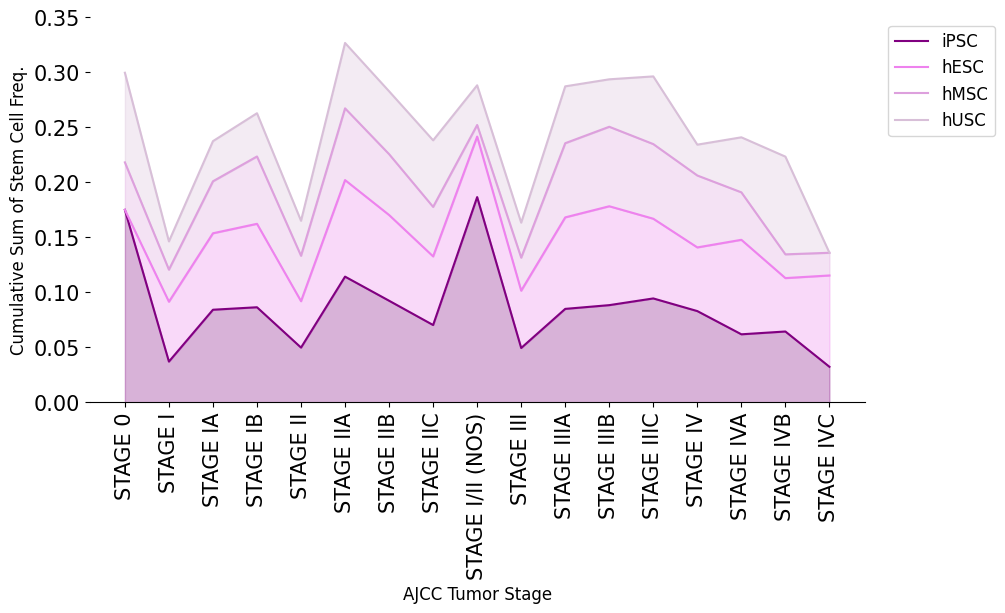

In [19]:
df = pd.DataFrame([ipsc_num, hesc_num, hmsc_num, husc_num], index=label_list, columns=stage_list).T

fig, ax = plt.subplots(figsize=(10, 5))
df.plot(kind='line', stacked=True, color=['purple', 'violet', 'plum', 'thistle'], alpha=1, ax=ax)

for i, cell_type in enumerate(df.columns):
    ax.fill_between(df.index, df.iloc[:, :i+1].sum(axis=1), df.iloc[:, :i].sum(axis=1) if i > 0 else 0, color=['purple', 'violet', 'plum', 'thistle'][i], alpha=0.3)

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=90, fontsize=15)
ax.tick_params(axis='y', labelsize=15)
legend = ax.legend(fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylabel("Cumulative Sum of Stem Cell Freq.", fontsize=12)
ax.set_xlabel("AJCC Tumor Stage", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_ylim(0, 0.35)
# plt.savefig('stage_mean_stem.png', dpi = 600, bbox_inches='tight')
plt.show()

Fig - 3.A (Stacked Line Plot CSC Freq. vs Metastasis Stage)

In [20]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [21]:
patient_cut = [i[:-3] for i in df.index]
patient_cut

['TCGA-05-4244',
 'TCGA-05-4249',
 'TCGA-05-4250',
 'TCGA-05-4382',
 'TCGA-05-4384',
 'TCGA-05-4389',
 'TCGA-05-4390',
 'TCGA-05-4395',
 'TCGA-05-4396',
 'TCGA-05-4397',
 'TCGA-05-4398',
 'TCGA-05-4402',
 'TCGA-05-4403',
 'TCGA-05-4405',
 'TCGA-05-4410',
 'TCGA-05-4415',
 'TCGA-05-4417',
 'TCGA-05-4418',
 'TCGA-05-4420',
 'TCGA-05-4422',
 'TCGA-05-4424',
 'TCGA-05-4425',
 'TCGA-05-4426',
 'TCGA-05-4427',
 'TCGA-05-4430',
 'TCGA-05-4432',
 'TCGA-05-4433',
 'TCGA-05-4434',
 'TCGA-05-5420',
 'TCGA-05-5423',
 'TCGA-05-5425',
 'TCGA-05-5428',
 'TCGA-05-5429',
 'TCGA-05-5715',
 'TCGA-35-3615',
 'TCGA-35-4122',
 'TCGA-35-4123',
 'TCGA-35-5375',
 'TCGA-38-4625',
 'TCGA-38-4625',
 'TCGA-38-4626',
 'TCGA-38-4626',
 'TCGA-38-4627',
 'TCGA-38-4627',
 'TCGA-38-4628',
 'TCGA-38-4629',
 'TCGA-38-4630',
 'TCGA-38-4631',
 'TCGA-38-4632',
 'TCGA-38-4632',
 'TCGA-38-6178',
 'TCGA-38-7271',
 'TCGA-38-A44F',
 'TCGA-44-2655',
 'TCGA-44-2655',
 'TCGA-44-2656',
 'TCGA-44-2657',
 'TCGA-44-2657',
 'TCGA-44-2659

In [22]:
patient_info = pd.read_csv('patient_info.csv')
patient_info

,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
0,TCGA-2K-A9WE,KIRP,KIRP,73292C19-D6A8-4BC4-97BC-CCCE54F264F8,53.0,Male,STAGE II,7TH,214.0,-19603.0,...,97.73,Yes,0:LIVING,7.035539,0:ALIVE OR DEAD TUMOR FREE,7.035539,0:DiseaseFree,7.035539,0:CENSORED,7.035539
1,TCGA-2Z-A9J1,KIRP,KIRP,851A1157-E460-4794-8534-2EB6F0AE7468,71.0,Male,STAGE I,6TH,2298.0,-26244.0,...,96.10,Yes,0:LIVING,75.549857,0:ALIVE OR DEAD TUMOR FREE,75.549857,0:DiseaseFree,75.549857,0:CENSORED,75.549857
2,TCGA-2Z-A9J2,KIRP,KIRP,95CB399C-0A6F-4BD8-8146-36F367F30611,71.0,Female,STAGE I,6TH,1795.0,-26134.0,...,62.50,Yes,0:LIVING,59.013052,0:ALIVE OR DEAD TUMOR FREE,59.013052,0:DiseaseFree,59.013052,0:CENSORED,59.013052
3,TCGA-2Z-A9J3,KIRP,KIRP,5195C9AC-B649-49F8-8750-F9A4787E8E52,67.0,Male,STAGE II,6TH,NaN,-24626.0,...,86.40,Yes,1:DECEASED,58.224019,1:DEAD WITH TUMOR,58.224019,NaN,NaN,1:PROGRESSION,25.972318
4,TCGA-2Z-A9J5,KIRP,KIRP,DA0289C6-FF84-4063-BA99-A0D0A338F6CD,80.0,Male,STAGE II,6TH,3050.0,-29275.0,...,105.20,Yes,0:LIVING,100.272874,0:ALIVE OR DEAD TUMOR FREE,100.272874,NaN,NaN,0:CENSORED,100.272874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10948,TCGA-VQ-AA6I,STAD_CIN,STAD,3CCBE7C7-C779-4A98-B495-FF020D3E9E55,68.0,Male,STAGE IIIB,7TH,NaN,-25091.0,...,NaN,Yes,1:DECEASED,16.142289,1:DEAD WITH TUMOR,16.142289,NaN,NaN,1:PROGRESSION,15.616267
10949,TCGA-VQ-AA6J,STAD_CIN,STAD,A267DDB4-B2D9-4292-B120-6E13E70D01F8,75.0,Male,STAGE IIIB,7TH,838.0,-27506.0,...,NaN,Yes,0:LIVING,27.550383,0:ALIVE OR DEAD TUMOR FREE,27.550383,0:DiseaseFree,27.550383,0:CENSORED,27.550383
10950,TCGA-VQ-AA6K,STAD_CIN,STAD,83A0F9EF-4BF0-4EFE-8713-F8B6AB4F5773,59.0,Male,STAGE IIIC,6TH,NaN,-21901.0,...,NaN,Yes,1:DECEASED,12.427261,1:DEAD WITH TUMOR,12.427261,NaN,NaN,1:PROGRESSION,10.914949
10951,TCGA-ZA-A8F6,STAD_CIN,STAD,9130C730-B0BC-4D3A-9EE1-09BF43D9BD67,71.0,Male,STAGE IB,7TH,525.0,-26122.0,...,NaN,Yes,0:LIVING,17.260085,0:ALIVE OR DEAD TUMOR FREE,17.260085,0:DiseaseFree,17.260085,0:CENSORED,17.260085


In [23]:
grade_mce = df.set_axis(patient_cut)
grade_mce = grade_mce[['predicted_label', 'stem']]

grade_patient = patient_info.set_index('PATIENT_ID')
grade_patient = grade_patient[['PATH_M_STAGE']]

common_grade = list(set(grade_mce.index) & set(grade_patient.index))

grade_mce = grade_mce[grade_mce.index.isin(common_grade)]
grade_mce = grade_mce[~grade_mce.index.duplicated(keep='first')]

grade_patient = grade_patient[grade_patient.index.isin(common_grade)]
grade_patient = grade_patient[~grade_patient.index.duplicated(keep='first')]

grade_data = pd.concat([grade_mce, grade_patient], axis=1).dropna()
grade_data

,predicted_label,stem,PATH_M_STAGE
TCGA-05-4244,hESC,0.018238,M1
TCGA-05-4249,hMSC,0.042426,M0
TCGA-05-4250,hMSC,0.071180,M0
TCGA-05-4382,hESC,0.037569,M0
TCGA-05-4384,hMSC,0.010948,M0
...,...,...,...
TCGA-KO-8413,hUSC,0.000000,M0
TCGA-KO-8414,hESC,0.009545,M0
TCGA-KO-8415,hUSC,0.013909,M0
TCGA-KO-8416,iPSC,0.006677,M0


In [24]:
grade_list = ['M0', 'M1', 'M1A', 'M1B', 'M1C', 'CM0 (I+)']
grouped_grade = grade_data.groupby('PATH_M_STAGE')
label_list = ['iPSC', 'hESC', 'hMSC', 'hUSC']

In [25]:
ipsc_gr = []
hmsc_gr = []
hesc_gr = []
husc_gr = []
for i in grade_list:
    grade_df = grouped_grade.get_group(i)
    try:
        ipsc_gr.append(grade_df[grade_df['predicted_label'] == 'iPSC']['stem'].mean())
    except:
        ipsc_gr.append(0)
    try:
        hmsc_gr.append(grade_df[grade_df['predicted_label'] == 'hMSC']['stem'].mean())
    except:
        hmsc_gr.append(0)
    try:
        hesc_gr.append(grade_df[grade_df['predicted_label'] == 'hESC']['stem'].mean())
    except:
        hesc_gr.append(0)
    try:
        husc_gr.append(grade_df[grade_df['predicted_label'] == 'hUSC']['stem'].mean())
    except:
        husc_gr.append(0)

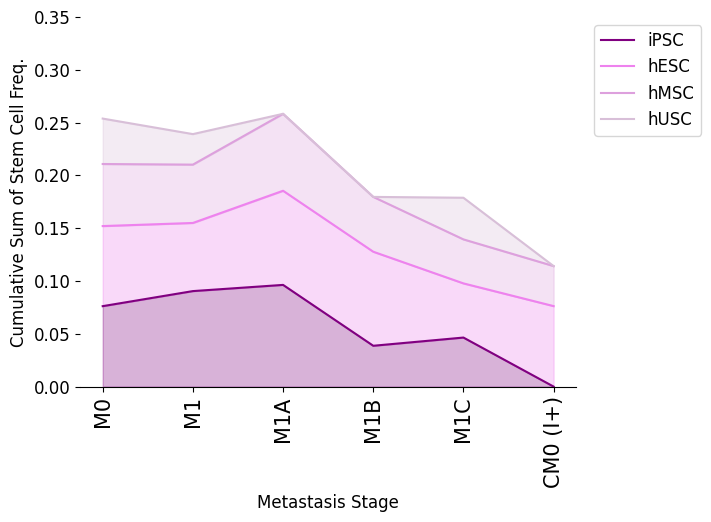

In [26]:
df = pd.DataFrame([ipsc_gr, hesc_gr, hmsc_gr, husc_gr], index=label_list, columns=grade_list).T

# fig, ax = plt.subplots(figsize=(5, 6))

ax = df.plot(kind='line', stacked=True, color=['purple', 'violet', 'plum', 'thistle'], alpha=1)

for i, cell_type in enumerate(df.columns):
    ax.fill_between(df.index, df.iloc[:, :i+1].sum(axis=1), df.iloc[:, :i].sum(axis=1) if i > 0 else 0, color=['purple', 'violet', 'plum', 'thistle'][i], alpha=0.3)

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=90, fontsize=15)
ax.tick_params(axis='y', labelsize=12)
legend = ax.legend(fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylabel("Cumulative Sum of Stem Cell Freq.", fontsize=12)
ax.set_xlabel("Metastasis Stage", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.ylim(0, 0.35)
# plt.savefig('metstasis_mean_stem.png', dpi = 600, bbox_inches='tight')

plt.show()

Fig -3.C,D,E (Kaplanmeier plot)

In [27]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
patient_cut = [i[:-3] for i in df.index]

In [28]:
patient_info = pd.read_csv('patient_info.csv')

In [29]:
kp_mce = df.set_axis(patient_cut)
kp_mce = kp_mce[['predicted_label']]

kp_patient = patient_info.set_index('PATIENT_ID')
kp_patient = kp_patient[['OS_STATUS','OS_MONTHS', 'DSS_STATUS','DSS_MONTHS',
                        'DFS_STATUS','DFS_MONTHS', 'PFS_STATUS','PFS_MONTHS']]

common_kp = list(set(kp_mce.index) & set(kp_patient.index))

kp_mce = kp_mce[kp_mce.index.isin(common_kp)]
kp_mce = kp_mce[~kp_mce.index.duplicated(keep='first')]

kp_patient = kp_patient[kp_patient.index.isin(common_kp)]
kp_patient = kp_patient[~kp_patient.index.duplicated(keep='first')]

kp_data = pd.concat([kp_mce, kp_patient], axis=1)
kp_data['OS_STATUS'] = [str(i)[0] if not pd.isnull(i) else np.nan for i in kp_data['OS_STATUS']]
kp_data['DFS_STATUS'] = [str(i)[0] if not pd.isnull(i) else np.nan for i in kp_data['DFS_STATUS']]
kp_data['DSS_STATUS'] = [str(i)[0] if not pd.isnull(i) else np.nan for i in kp_data['DSS_STATUS']]
kp_data['PFS_STATUS'] = [str(i)[0] if not pd.isnull(i) else np.nan for i in kp_data['PFS_STATUS']]
kp_data

,predicted_label,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
TCGA-05-4244,hESC,0,0.000000,0,0.000000,NaN,NaN,0,0.000000
TCGA-05-4249,hMSC,0,50.070684,0,50.070684,NaN,NaN,0,50.070684
TCGA-05-4250,hMSC,1,3.978039,NaN,3.978039,NaN,NaN,0,3.978039
TCGA-05-4382,hESC,0,19.955946,0,19.955946,1,10.980702,1,10.980702
TCGA-05-4384,hMSC,0,14.005326,0,14.005326,NaN,NaN,1,6.016372
...,...,...,...,...,...,...,...,...,...
TCGA-61-2113,iPSC,1,22.224414,NaN,22.224414,NaN,NaN,1,9.567018
TCGA-OY-A56P,iPSC,0,39.681757,0,39.681757,1,26.103824,1,26.103824
TCGA-OY-A56Q,iPSC,0,18.936779,0,18.936779,0,18.936779,0,18.936779
TCGA-VG-A8LO,iPSC,1,0.789032,1,0.789032,NaN,NaN,1,0.789032


nan
nan


<Figure size 300x100 with 0 Axes>

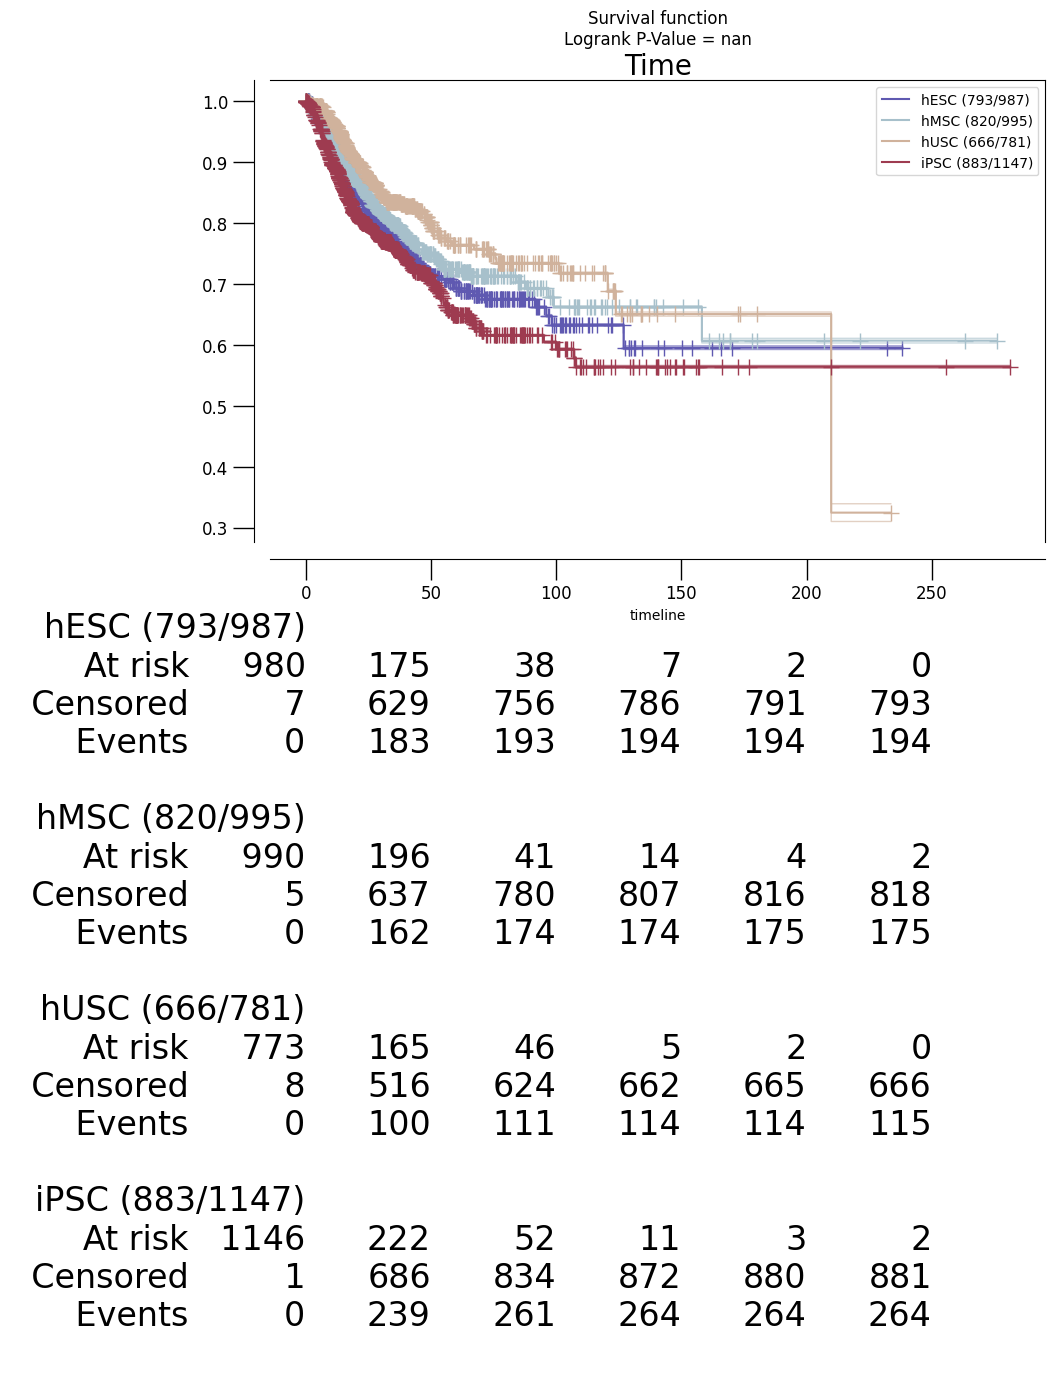

In [30]:
import kaplanmeier as km
import matplotlib.pyplot as plt

# change to OS, PFS, and DSS to get the desired plot
patient_os = kp_data[['predicted_label', 'DFS_STATUS','DFS_MONTHS']].dropna()
time_event = patient_os['DFS_MONTHS']
censoring = patient_os['DFS_STATUS']
y = patient_os['predicted_label']

results = km.fit(time_event, censoring, y)

plt.figure(figsize=(3, 1))

km.plot(results, cmap='twilight_shifted', cii_lines=True, cii_alpha=0.05)

p_value = results['logrank_P']
z_value = results['logrank_Z']
plt.xticks(fontsize=24)
plt.yticks(fontsize=20)

plt.xlabel("Time", fontsize=20)
plt.ylabel("Survival Probability", fontsize=20)

# plt.savefig("survival_os.png", dpi=600, bbox_inches='tight')
print(p_value)
print(z_value)
plt.show()

Fig - 3.F, G, H (Cox Regression plot) - R code

In [ ]:
''''
library(casebase)
library(visreg)
library(splines)
library(ggplot2)

data1 = read.csv2('kp_data.csv', sep=',')
data1$PFS_MONTHS <- as.numeric(data1$PFS_MONTHS)

mod_cb <- fitSmoothHazard(PFS_STATUS ~ ns((PFS_MONTHS), df = 3) + predicted_label,
                          data = data1,
                          time = "PFS_MONTHS")

plot(mod_cb,
     hazard.params = list(xvar = "PFS_MONTHS",
                          by = "predicted_label",
                          alpha = 0.05,
                          ylab = "Hazard"),
     col = c("maroon", "orchid", "palevioletred1", "pink")) 

Fig - 4.A (Chirnoff's face)

Fig - 4.B (Volcanco Plot)

Fig - 4.C (Upset Plot)

In [47]:
import pandas as pd
df = pd.read_csv('deseq_tumor_stem.csv', index_col=(0))
df = df[(df['log2FoldChange'] > 2) & (df['padj'] < 0.05)]
df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
NMBR,326.57758,4.329424,0.072298,59.883341,0.000000e+00,0.000000e+00
ARTN,338.67712,2.258884,0.041164,54.875131,0.000000e+00,0.000000e+00
OR10Z1,169.28561,3.571139,0.169817,21.029300,3.538308e-98,5.338072e-98
MNX1,315.09314,2.674213,0.053874,49.638621,0.000000e+00,0.000000e+00
ZNF441,373.95720,2.511478,0.031479,79.783093,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
ZNF41,369.83362,2.253609,0.029405,76.639863,0.000000e+00,0.000000e+00
NHLH1,363.20460,2.910942,0.040627,71.650016,0.000000e+00,0.000000e+00
TBX21,356.90076,3.585813,0.038767,92.497569,0.000000e+00,0.000000e+00
AOC2,368.92892,2.465270,0.034681,71.084640,0.000000e+00,0.000000e+00


In [36]:
df2 = pd.read_csv('hUSC vs rest.csv', index_col=(0))
df2 = df2[(df2['log2FoldChange'] > 2) & (df2['padj'] < 0.05)]
df2

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A2BP1,5296.091805,3.527332,0.114523,30.800320,2.594679e-208,3.012669e-207
ACBD7,15505.205715,2.022801,0.046930,43.102692,0.000000e+00,0.000000e+00
ACCN2,37882.640679,2.451588,0.047073,52.081005,0.000000e+00,0.000000e+00
ACCN4,16615.948989,4.455303,0.092821,47.998833,0.000000e+00,0.000000e+00
ACSBG1,11901.484710,3.784321,0.057965,65.286855,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
ZIC3,734.054772,2.277522,0.165290,13.778962,3.411428e-43,8.253442e-43
ZNF488,13456.906901,2.466401,0.062793,39.278442,0.000000e+00,0.000000e+00
ZNF536,3364.502675,2.438020,0.092033,26.490775,1.238009e-154,9.318944e-154
ZNF804A,3492.962330,2.056769,0.052608,39.096174,0.000000e+00,0.000000e+00


In [37]:
df3 = pd.read_csv('hMSC vs rest.csv', index_col=(0))
df3 = df3[(df3['log2FoldChange'] > 2) & (df3['padj'] < 0.05)]
df3

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A4GNT,910.003637,2.121014,0.095640,22.176953,5.733276e-109,1.037290e-107
AHSP,316.498118,2.369070,0.129839,18.246142,2.220492e-74,2.326088e-73
ANXA10,22834.186800,2.181679,0.154653,14.106916,3.443100e-45,1.912165e-44
ATP4B,766.575023,2.064086,0.122940,16.789358,2.919880e-63,2.466026e-62
AZU1,4795.065895,3.603753,0.106947,33.696500,6.505080e-249,3.804724e-247
...,...,...,...,...,...,...
TPO,136591.914871,5.059502,0.121428,41.666810,0.000000e+00,0.000000e+00
TRY6,4466.405567,2.180608,0.159425,13.677962,1.374924e-42,7.194140e-42
UBQLN3,15.696226,2.035110,0.273525,7.440297,1.004590e-13,2.236891e-13
VSIG1,29983.307033,2.584658,0.073716,35.062314,2.531301e-269,1.752452e-267


In [38]:
df4 = pd.read_csv('hESC vs rest.csv', index_col=(0))
df4 = df4[(df4['log2FoldChange'] > 2) & (df4['padj'] < 0.05)]
df4

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AFP,12063.244079,3.229475,0.150226,21.497455,1.644627e-102,4.003958e-101
AMY2A,4630.601636,3.088587,0.098799,31.261164,1.574316e-214,1.324052e-212
AQP8,5104.711132,4.086621,0.104554,39.086119,0.000000e+00,0.000000e+00
C20orf70,899.122088,2.423475,0.173954,13.931691,4.066132e-44,2.840988e-43
C21orf54,2.343009,2.041026,0.536656,3.803226,1.428241e-04,2.211074e-04
...,...,...,...,...,...,...
TMIGD1,497.782795,3.367281,0.247705,13.593893,4.352973e-42,2.868115e-41
TNP1,12.628208,2.298563,0.384441,5.978970,2.245536e-09,4.543532e-09
TTTY7,2.894946,2.117398,0.629665,3.362737,7.717377e-04,1.136143e-03
VCY,115.640377,2.106061,0.506682,4.156574,3.230563e-05,5.211353e-05


In [39]:
df5 = pd.read_csv('iPSC vs rest.csv', index_col=(0))
df5 = df5[(df5['log2FoldChange'] > 2) & (df5['padj'] < 0.05)]
df5

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,251763.287592,3.282034,0.066213,49.567478,0.000000e+00,0.000000e+00
A2ML1,108827.229102,3.206642,0.101941,31.455763,3.501101e-217,7.572200e-216
AADAC,44777.539776,2.309676,0.114375,20.193816,1.109552e-90,5.999365e-90
ABCB11,4075.843806,3.323273,0.110935,29.957041,3.562380e-197,6.450317e-196
ABCB4,23495.819872,2.269167,0.059128,38.376981,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
WFDC5,4843.388521,2.556400,0.130208,19.633126,8.060035e-86,4.095826e-85
XIRP2,4620.536387,4.762414,0.135284,35.203106,1.792257e-271,6.039076e-270
ZAN,293.381725,2.392786,0.131941,18.135313,1.677420e-73,7.196217e-73
ZNF750,40354.330429,2.007928,0.065153,30.818668,1.473417e-208,2.966071e-207


In [49]:
from upsetplot import from_contents
data = from_contents({
    'Tumor': set(df.index),
    'iPSC': set(df5.index),
    'hESC': set(df4.index),
    'hMSC': set(df3.index),
    'hUSC': set(df2.index)
})
data

id
Tumor iPSC  hESC  hMSC  hUSC            
True  False False False False      REG3A
      True  False False False       AHSG
      False True  False False     GUCA2A
            False False False      SOX14
                        False      FOLH1
...                                  ...
False False False False True     JAKMIP1
                        True        RBP3
                        True   C14orf132
                        True    C13orf26
                        True        HPCA

[3068 rows x 1 columns]

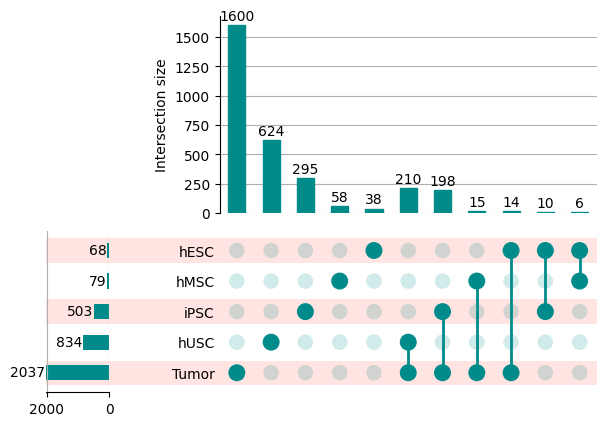

In [50]:
from upsetplot import plot
from matplotlib import pyplot as plt

ax_dict = plot(data, subset_size='count',
               show_counts=True, show_percentages=False,
              facecolor="darkcyan", shading_color="mistyrose")
# plt.savefig('upset_plot.png', dpi=600, bbox_inches='tight')
plt.show()

Fig - 4.D (Dendogram)

Fig - 4.E (Stemness Marker Gene DeSEq)

In [52]:
mark = pd.read_csv('stem_marker.csv')
mark = list(mark['Merged'].drop_duplicates())
mark

['AAAS',
 'AASDHPPT',
 'ABCB8',
 'ABCE1',
 'ADH5',
 'ADHFE1',
 'ADPGK',
 'ADSL',
 'AGPAT5',
 'AHI1',
 'AKT1S1',
 'ALAD',
 'AMD1',
 'AMH',
 'ANAPC10',
 'ANKRD10',
 'ANP32B',
 'ARFRP1',
 'ARMC8',
 'ARMET',
 'ARV1',
 'ATAD2',
 'ATAD3A',
 'ATF4',
 'ATF7',
 'ATIC',
 'ATP5C1',
 'ATP5E',
 'ATP5G2',
 'ATP6V1F',
 'ATPIF1',
 'AURKB',
 'B3GNT7',
 'BCLAF1',
 'BIRC2',
 'BIVM',
 'BLM',
 'BRD8',
 'BRE',
 'BXDC2',
 'CACYBP',
 'CANX',
 'CBX3',
 'CBX5',
 'CCND1',
 'CCNI',
 'CCT3',
 'CCT4',
 'CCT7',
 'CCT8',
 'CDK4',
 'CDT1',
 'CETN3',
 'CFL1',
 'CHCHD1',
 'CIRH1A',
 'CLNS1A',
 'CLPP',
 'CNIH4',
 'CNOT4',
 'COG4',
 'COX5A',
 'COX8A',
 'CRAT',
 'CSDE1',
 'CSNK2A1',
 'CSTF1',
 'DARS',
 'DBR1',
 'DBT',
 'DDB1',
 'DDX17',
 'DDX31',
 'DDX5',
 'DDX54',
 'DERL2',
 'DHX9',
 'DLST',
 'DNAJB4',
 'DNAJC8',
 'DPH3',
 'DTL',
 'EBNA1BP2',
 'EEF1A1',
 'EEF1B2',
 'EEF2',
 'EIF2S2',
 'EIF3S10',
 'EIF3S9',
 'EIF4A2',
 'EIF5A',
 'ELK4',
 'ENO3',
 'EPRS',
 'ERH',
 'ESPL1',
 'EWSR1',
 'EXOSC1',
 'FCHSD2',
 'FN1',
 'FNBP4',
 

In [54]:
df = pd.read_csv('iPSC vs rest.csv', index_col=(0)) # change to hESC, hMSC, hUSC for respective plot
df = df[df.index.isin(mark)]
df = df.sort_values(by=['log2FoldChange'], ascending=False)
df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENO3,20070.257126,1.702938,0.044719,38.080529,0.000000e+00,0.000000e+00
CYP26A1,4602.160492,1.194189,0.074728,15.980433,1.749268e-57,5.935495e-57
SDC1,978075.343933,1.176807,0.042223,27.870946,6.004960e-171,8.428479e-170
ITGA6,529001.773183,1.138854,0.032600,34.934591,2.219576e-267,7.204596e-266
L1TD1,2829.610887,1.069133,0.068458,15.617347,5.546580e-55,1.817778e-54
...,...,...,...,...,...,...
ETV1,99528.426387,-1.623767,0.047100,-34.474930,1.905694e-260,5.903300e-259
SALL2,55005.106918,-1.647679,0.041328,-39.868483,0.000000e+00,0.000000e+00
ZIC3,654.719585,-2.095536,0.157765,-13.282666,2.918161e-40,7.682113e-40
CX3CR1,32811.810416,-2.351934,0.048936,-48.061737,0.000000e+00,0.000000e+00


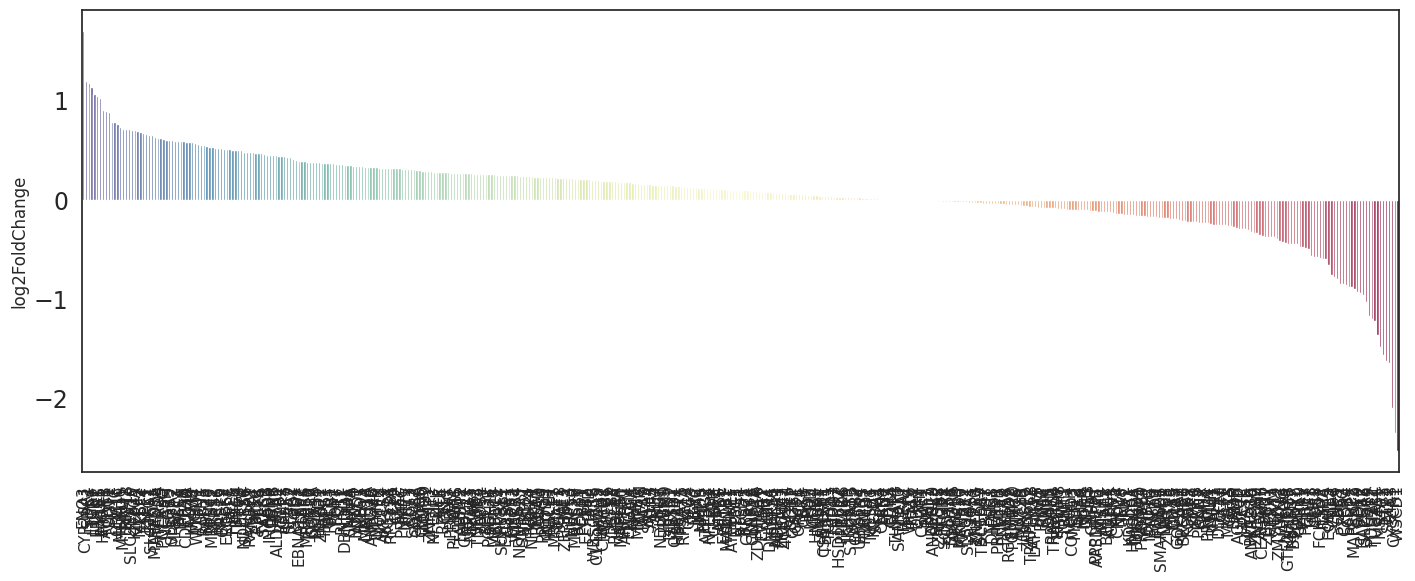

In [58]:
sns.set(rc={'figure.figsize':(17,6)})
sns.set_style('white')
sns.barplot(x = df.index, y = df['log2FoldChange'], 
            palette='Spectral_r')
plt.xticks(rotation=90)
plt.yticks(fontsize=17)
# plt.savefig('fold_cancer_stem.png', dpi=600, bbox_inches='tight')
plt.show()

Fig - 4.F (GSEA up vs down VENN Diagram)

In [65]:
df = pd.read_csv('gsea_stem_ipsc.csv', index_col=(0))
df = df[pd.notna(df['Term'])]
df = df[df['NOM p-val'] < 0.05]
df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Epidermis Development (GO:0008544),-0.716902,-2.265282,0.000000,0.012143,0.009,43/79,10.86%,GJB5;KRT5;DSP;KRT14;OVOL1;GRHL3;SPRR1B;ZNF750;...
1,gsea,Response To Axon Injury (GO:0048678),0.754947,2.133215,0.000000,0.090907,0.046,10/17,14.41%,SARM1;MORN4;P2RY12;DPYSL3;P2RX4;MAPK8IP3;TREM2...
2,gsea,Cardiac Ventricle Development (GO:0003231),0.746248,2.128243,0.000000,0.048127,0.049,11/19,16.73%,PDE2A;MATR3;HEYL;DLL4;HEY1;MDM4;ENG;GATA3;SALL...
3,gsea,Antimicrobial Humoral Immune Response Mediated...,-0.594435,-2.065824,0.000000,0.146352,0.193,23/56,18.32%,KRT6A;S100A9;PGLYRP3;PGLYRP4;RNASE7;S100A7;RPS...
4,gsea,Protein Localization To Cilium (GO:0061512),0.689229,1.999630,0.000000,0.373430,0.361,23/35,23.90%,TCTN1;WDR19;CC2D2A;WDR35;BBS1;TUB;TTC21A;TCTN2...
...,...,...,...,...,...,...,...,...,...,...
717,gsea,Negative Regulation Of Transmembrane Receptor ...,0.377518,1.434072,0.046602,0.597212,1.000,65/105,45.92%,MAGI2;SAP30L;HIPK2;SIRT1;ARID4A;SAP30;OGT;SPRE...
720,gsea,Epithelial Cilium Movement Involved In Determi...,0.769915,1.433658,0.048780,0.595361,1.000,5/5,23.03%,CCDC40;NPHP3;CCDC39;OFD1;RFX3
722,gsea,Positive Regulation Of Protein Kinase Activity...,0.357842,1.433318,0.034091,0.594367,1.000,62/141,34.62%,MAP3K12;RASSF2;RAPGEF2;CSF1R;DLG4;FCGR1A;CCDC8...
849,gsea,Negative Regulation Of Neuron Apoptotic Proces...,0.357844,1.396947,0.049336,0.610884,1.000,37/69,42.39%,CX3CR1;BCL2;MEF2C;WFS1;MT3;PPT1;IL6ST;NAIP;PTP...


In [64]:
df2 = pd.read_csv('gsea_stem_hesc.csv', index_col=(0))
df2 = df2[pd.notna(df2['Term'])]
df2 = df2[df2['NOM p-val'] < 0.05]
df2

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Cholesterol Biosynthetic Process (GO:0006695),-0.831684,-2.181105,0.000000,0.016123,0.038,19/22,12.84%,HSD17B7;DHCR24;NSDHL;LBR;DHCR7;INSIG1;CYP51A1;...
1,gsea,Secondary Alcohol Biosynthetic Process (GO:190...,-0.831684,-2.181105,0.000000,0.016123,0.038,19/22,12.84%,HSD17B7;DHCR24;NSDHL;LBR;DHCR7;INSIG1;CYP51A1;...
2,gsea,Sterol Biosynthetic Process (GO:0016126),-0.787124,-2.138771,0.000000,0.022537,0.071,20/25,12.84%,HSD17B7;DHCR24;SQLE;NSDHL;LBR;DHCR7;INSIG1;CYP...
3,gsea,Regulation Of Potassium Ion Transmembrane Tran...,0.649833,2.069596,0.000000,0.402192,0.150,17/32,19.21%,DPP6;KCNIP3;KCNAB1;BIN1;KCNIP4;KCNIP1;KCNAB3;Y...
4,gsea,Regulation Of Postsynapse Organization (GO:009...,0.705162,2.048959,0.000000,0.287072,0.189,14/23,18.56%,ZDHHC15;SHANK3;ARHGAP22;EPHA4;CDK5R1;HOMER1;KI...
...,...,...,...,...,...,...,...,...,...,...
1080,gsea,Positive Regulation Of Macromolecule Metabolic...,0.305639,1.404742,0.027076,0.446403,1.000,180/341,43.54%,MEF2C;ANK2;FGF1;PDE2A;MSN;POU3F3;CALCOCO1;CLU;...
1083,gsea,Negative Regulation Of Cell Population Prolife...,0.320095,1.404327,0.023576,0.445911,1.000,177/344,44.92%,KAT2B;PML;APC;RAPGEF2;TOB2;DAB2IP;RPS6KA2;IGFB...
1166,gsea,Negative Regulation Of Cellular Process (GO:00...,0.317048,1.383943,0.031873,0.462396,1.000,257/483,45.49%,KAT2B;JAM2;PML;APC;RAPGEF2;CLU;TOB2;EPHA4;DAB2...
1224,gsea,Negative Regulation Of Signal Transduction (GO...,0.312850,1.373172,0.047706,0.465147,1.000,113/248,37.90%,PRKCQ;MEGF8;PALM;INPP5K;CITED1;TYRO3;DAB2IP;BE...


In [62]:
df3 = pd.read_csv('gsea_stem_hmsc.csv', index_col=(0))
df3 = df3[pd.notna(df3['Term'])]
df3 = df3[df3['NOM p-val'] < 0.05]
df3

,Unnamed: 0,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,gsea,Pyruvate Metabolic Process (GO:0006090),0.675413,2.273078,0.000000,0.004413,0.005,23/47,10.30%,ALDOC;ENO1;PGAM1;PKLR;TPI1;PCK2;KRT17;ALDOB;PC...
1,1,gsea,L-amino Acid Transport (GO:0015807),0.717789,2.132535,0.000000,0.048545,0.061,16/26,14.70%,SLC1A3;SLC38A3;SFXN1;SLC3A2;SLC7A5;SLC22A2;SLC...
2,2,gsea,Amino Acid Import Across Plasma Membrane (GO:0...,0.655602,2.085729,0.000000,0.065020,0.118,15/27,14.22%,SLC1A3;SLC1A2;SLC38A3;SLC3A2;SLC38A4;SLC7A5;SL...
3,3,gsea,Glycolytic Process (GO:0006096),0.709786,2.078878,0.000000,0.055606,0.130,20/27,20.57%,ALDOC;ENO1;PGAM1;PKLR;TPI1;ALDOB;GPI;PFKM;ENO2...
4,4,gsea,Negative Regulation Of Lipopolysaccharide-Medi...,-0.790401,-1.992264,0.000000,1.000000,0.397,3/10,6.61%,TRIB1;CARD8;SIGIRR
...,...,...,...,...,...,...,...,...,...,...,...
557,557,gsea,Negative Regulation Of Transcription By Compet...,-0.623187,-1.470240,0.047710,1.000000,1.000,6/8,26.65%,HHEX;MUC1;CREB1;SMAD7;KDM2A;DACH1
572,572,gsea,Dosage Compensation (GO:0007549),-0.745366,-1.464799,0.037037,1.000000,1.000,5/6,17.22%,RBM15B;METTL3;SMCHD1;YTHDC1;RBM15
592,592,gsea,Response To Metal Ion (GO:0010038),0.383755,1.457993,0.036660,0.470868,1.000,25/61,25.39%,KHK;TFR2;IMPA2;HAAO;FGB;NDRG1;FGA;FGG;MAPT;AQP...
598,598,gsea,Protein Polymerization (GO:0051258),0.389213,1.455950,0.043651,0.471896,1.000,22/56,19.05%,KRT5;FAM107A;FGB;FGA;TPPP2;FGG;WASF1;SPIRE1;TP...


In [63]:
df4 = pd.read_csv('gsea_stem_husc.csv', index_col=(0))
df4 = df4[pd.notna(df4['Term'])]
df4 = df4[df4['NOM p-val'] < 0.05]
df4

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Central Nervous System Neuron Differentiation ...,0.784968,2.194822,0.000000,0.050792,0.027,12/26,5.02%,NOVA2;MAP2;FAIM2;MAPT;CEND1;NTRK2;OPHN1;GRID2;...
1,gsea,Anterograde Trans-Synaptic Signaling (GO:0098916),0.591236,2.134350,0.000000,0.081679,0.075,104/198,26.40%,NLGN1;SLC1A3;DTNA;NRXN2;APBA2;NLGN3;NLGN2;GRIK...
2,gsea,Synapse Organization (GO:0050808),0.603887,2.117067,0.000000,0.074587,0.098,63/127,19.58%,NLGN1;CTNND2;GPM6A;LRRC4B;NRXN2;DNER;NRCAM;DNM...
3,gsea,Metal Ion Transport (GO:0030001),0.529155,2.101874,0.000000,0.072413,0.122,90/166,30.16%,CACNG7;FYN;KCNJ10;TRPC1;ATP1A2;SCN4B;CALCRL;SC...
4,gsea,Chemical Synaptic Transmission (GO:0007268),0.589835,2.100947,0.000000,0.059578,0.126,142/268,26.00%,NLGN1;SLC1A3;DTNA;NRXN2;GRIA3;APBA2;NLGN3;GRIA...
...,...,...,...,...,...,...,...,...,...,...
994,gsea,Positive Regulation Of Actin Filament Bundle A...,0.404197,1.451932,0.039130,0.359079,1.000,23/48,38.35%,CCDC88A;LIMCH1;ARHGEF10;PPM1E;CX3CL1;FERMT2;GP...
1002,gsea,Positive Regulation Of Protein Phosphorylation...,0.314522,1.449829,0.029680,0.360806,1.000,168/355,37.38%,CLIP3;PINK1;RASSF2;NTRK3;FGF2;GDF1;FGF1;AKTIP;...
1034,gsea,Negative Regulation Of Protein-Containing Comp...,0.393809,1.439597,0.044990,0.370044,1.000,23/53,37.84%,THRA;CRYAB;JAM3;ANKS1B;PRRT2;TREM2;CARD8;CLU;H...
1125,gsea,mRNA 5'-Splice Site Recognition (GO:0000395),0.925901,1.417053,0.017964,0.387710,1.000,1/2,2.12%,PSIP1


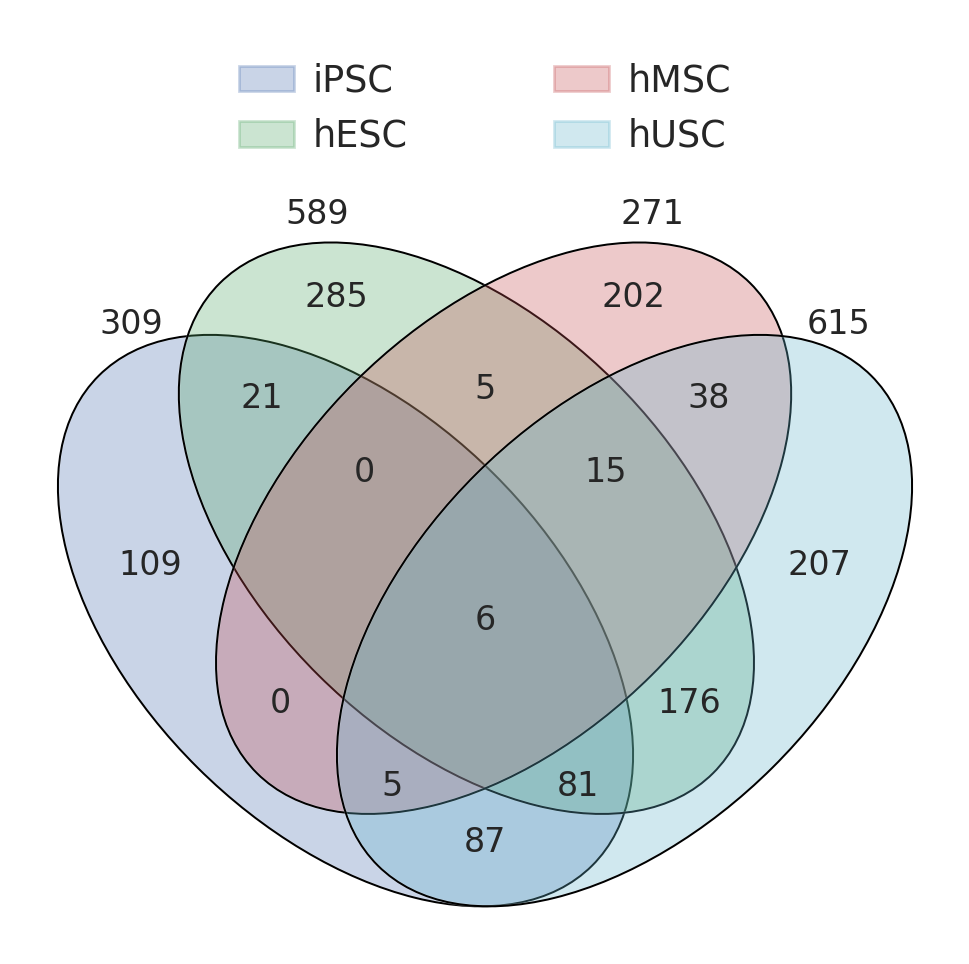

In [66]:
from venny4py.venny4py import *
%matplotlib inline

sets = {
    'iPSC': set(df[df['NES'] > 0]['Term']),
    'hESC': set(df2[df2['NES'] > 0]['Term']),
    'hMSC': set(df3[df3['NES'] > 0]['Term']),
    'hUSC': set(df4[df4['NES'] > 0]['Term'])
}

venny4py(sets=sets, size=6, dpi=600)

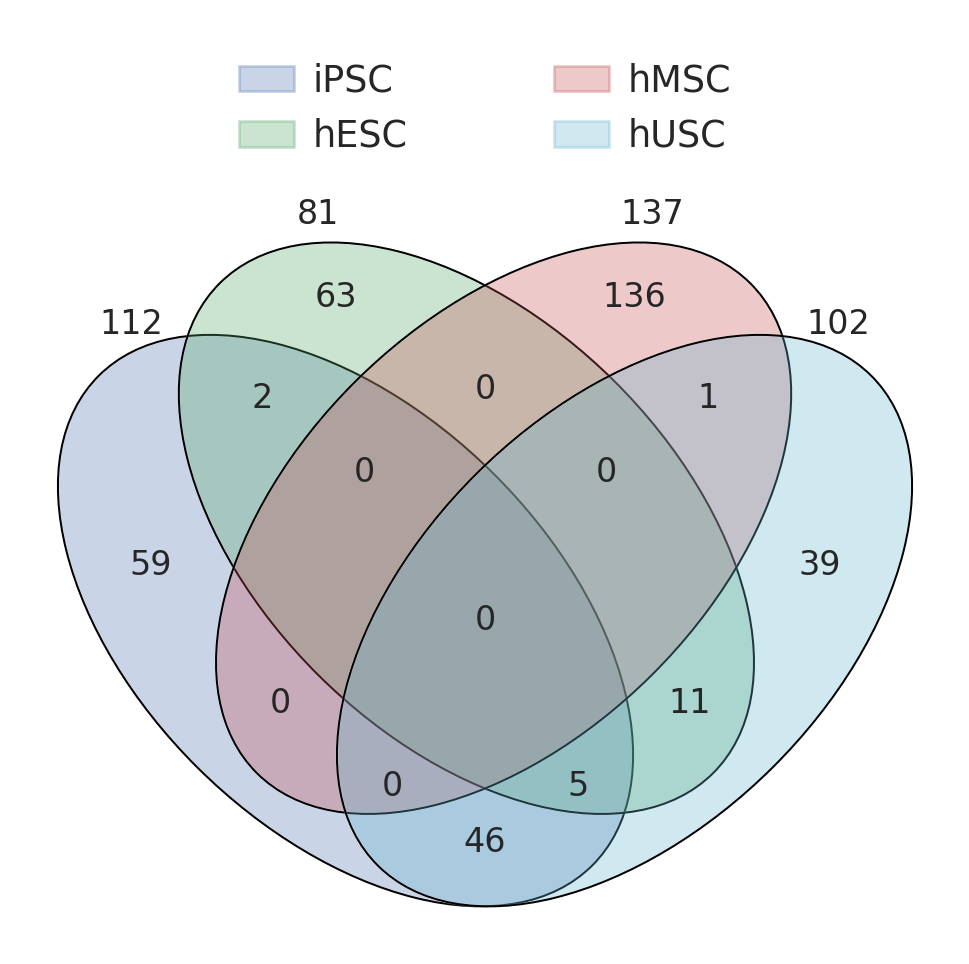

In [67]:
from venny4py.venny4py import *
%matplotlib inline

sets = {
    'iPSC': set(df[df['NES'] < 0]['Term']),
    'hESC': set(df2[df2['NES'] < 0]['Term']),
    'hMSC': set(df3[df3['NES'] < 0]['Term']),
    'hUSC': set(df4[df4['NES'] < 0]['Term'])
}

venny4py(sets=sets, size=6, dpi=600)

Fig - 5.A

Fig - 5.B

Fig - 5.C and D

In [68]:
df = pd.read_csv('22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [69]:
group = df.groupby('Cancer')
req = []
for i in df['Cancer'].unique():
    df = group.get_group(i)
    if i == 'LUAD' or 'LUSC':
        df = df.drop(['LUAD'], axis=1)
        df['Sum'] = (df.iloc[:,12:]).sum(axis=1)
        req.append(df)
    else:
        df = df.drop([i], axis=1)
        df['Sum'] = (df.iloc[:,12:]).sum(axis=1)
        req.append(df)

In [70]:
df = pd.concat(req, axis=0)
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC,Sum
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705,0.586806
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833,0.674682
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172,0.779252
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875,0.855963
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030,0.732963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472,0.853139
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270,0.753147
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669,0.797912
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816,0.843747


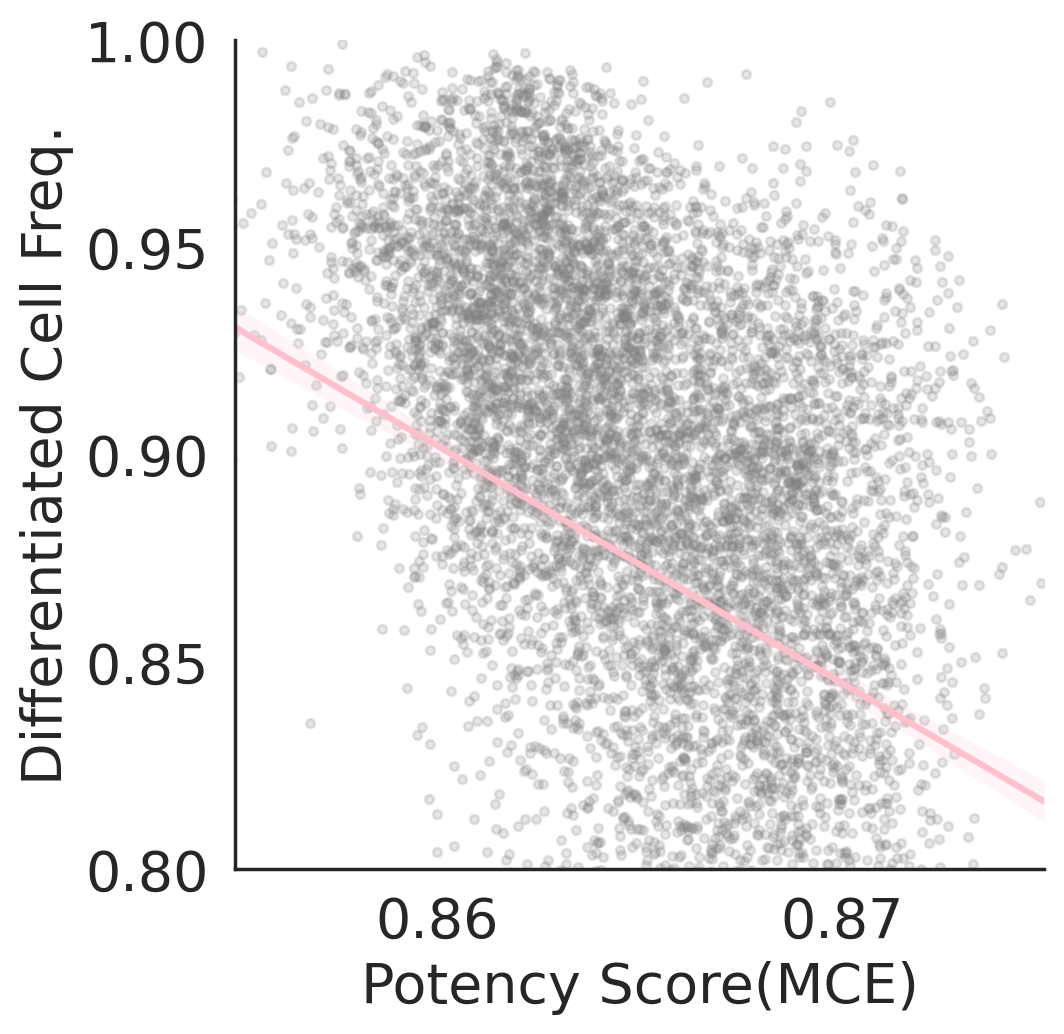

In [74]:
sns.set_style('white')

sns.lmplot(x ='MCE', y ='Sum', data = df, scatter=True,
          scatter_kws={'color': 'gray', 's': 10, 'alpha': 0.2}, line_kws={'color': 'pink'},
           ci=95)
ax = plt.gca()
plt.ylim(0.8, 1.0)
plt.xlim(0.855, 0.875)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Differentiated Cell Freq.', fontsize=20)
ax.set_xlabel('Potency Score(MCE)', fontsize=20)
# plt.savefig('reg_mce_sum.png', dpi=600, bbox_inches='tight')
plt.show()

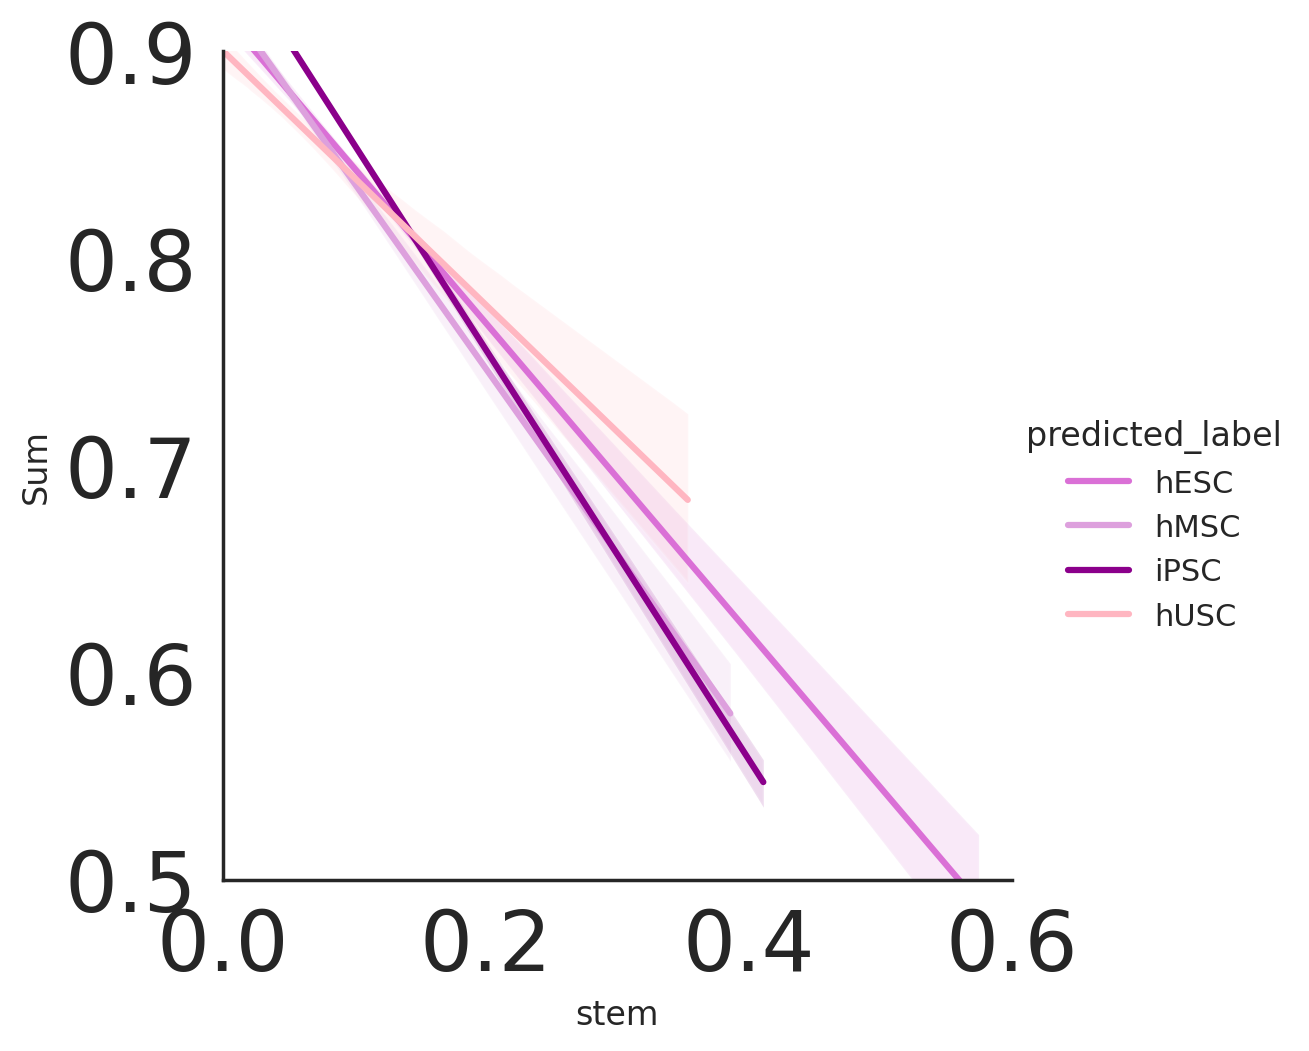

In [77]:
custom_palette = {
    'iPSC': 'darkmagenta',
    'hESC': 'orchid',
    'hMSC': 'plum',
    'hUSC': 'lightpink'
}

sns.set_style('white')

sns.lmplot(x ='stem', y ='Sum', data = df, 
           hue ='predicted_label', scatter=False,
          palette=custom_palette)
ax = plt.gca()
plt.ylim(0.5, 0.9)
plt.xlim(0.0, 0.6)
ax.tick_params(axis='y', labelsize=30)
ax.tick_params(axis='x', labelsize=30)
plt.show()